In [ ]:
# Import necessary packages
import cv2
import numpy as np
import imutils
from imutils.contours import sort_contours
from imutils import build_montages
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import SGD
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from google.colab.patches import cv2_imshow

In [2]:
pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.8/286.8 kB 16.6 MB/s eta 0:00:00


In [3]:
from easyocr import Reader

In [61]:
# Load model
model = load_model('/content/handwriting_model.h5')

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 810ms/step
[Handwriting OCR] G - 91.16%
[Handwriting OCR] T - 54.55%
[Handwriting OCR] T - 56.49%
[Handwriting OCR] T - 55.52%
[Handwriting OCR] M - 99.86%
[Handwriting OCR] B - 57.64%
[Handwriting OCR] H - 50.33%
[Handwriting OCR] U - 92.81%
[Handwriting OCR] L - 74.73%
[Handwriting OCR] W - 78.44%
[Handwriting OCR] W - 99.76%
[Handwriting OCR] W - 67.66%
[Handwriting OCR] G - 69.59%
[Handwriting OCR] J - 71.53%
[Handwriting OCR] U - 87.56%
[Handwriting OCR] G - 96.62%
[Handwriting OCR] H - 54.39%
[Handwriting OCR] M - 100.00%
[Handwriting OCR] G - 76.47%
[Handwriting OCR] G - 62.49%
[Handwriting OCR] G - 80.47%
[Handwriting OCR] G - 96.73%
[Handwriting OCR] G - 50.65%
[Handwriting OCR] G - 73.15%
[Handwriting OCR] G - 96.17%
[Handwriting OCR] W - 84.06%
[Handwriting OCR] G - 98.88%
[Handwriting OCR] E - 66.30%
[Handwriting OCR] W - 96.30%
[Handwriting OCR] W - 100.00%
[Handwriting OCR] F - 86.04%
[INFO] OCR'ing input image using EasyOCR...
[EasyOCR] Kymax 

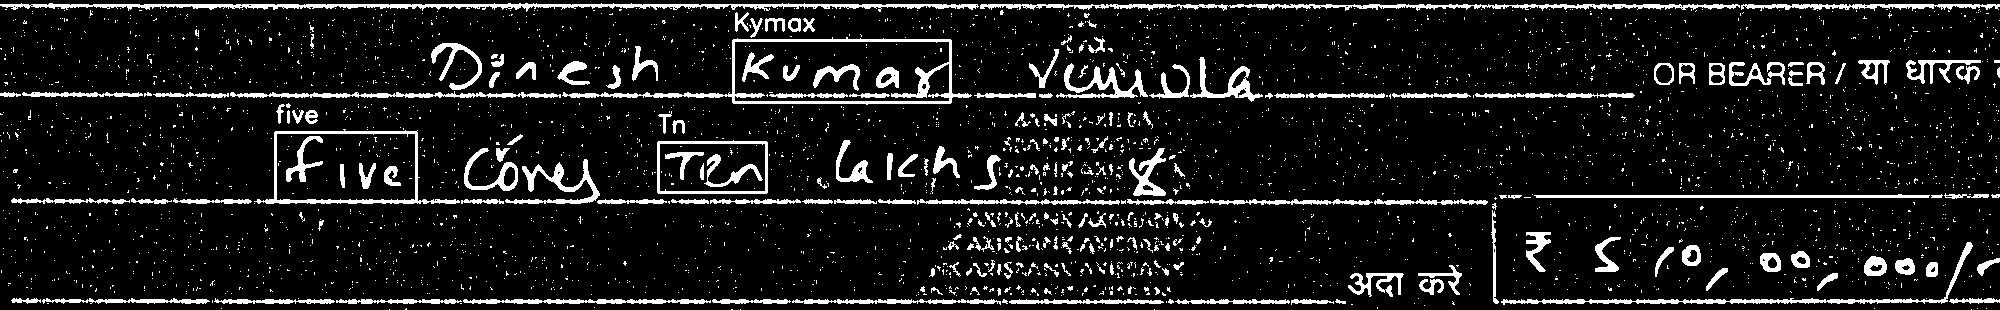

In [154]:
from google.colab.patches import cv2_imshow  # Import for displaying images in Colab

def process_and_ocr(image_path, model, reader):
    """
    Processes the input image, performs OCR using the handwriting model and EasyOCR,
    and displays the results.
    """
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("[ERROR] Unable to load image. Check the path.")
        return

    # Step 1: Preprocessing
    gray = get_grayscale(img)
    denoised = remove_noise(gray)
    thresh = thresholding(denoised)
    cropped = cropping(thresh)

    # Step 2: Contour Detection and Handwriting OCR
    edged = cv2.Canny(cropped, 30, 150)
    cnts = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    cnts = sort_contours(cnts, method="left-to-right")[0]

    chars = []
    for c in cnts:
        (x, y, w, h) = cv2.boundingRect(c)
        aspect_ratio = w / float(h)
        area = cv2.contourArea(c)

        # Filter bounding boxes based on size, aspect ratio, and area
        if 50 <= area <= 5000 and 0.2 <= aspect_ratio <= 1.5 and (w >= 5 and w <= 150) and (h >= 15 and h <= 120):
            roi = gray[y:y + h, x:x + w]
            roi_thresh = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
            (tH, tW) = roi_thresh.shape

            # Resize the ROI to maintain aspect ratio
            if tW > tH:
                roi_thresh = imutils.resize(roi_thresh, width=32)
            else:
                roi_thresh = imutils.resize(roi_thresh, height=32)

            (tH, tW) = roi_thresh.shape
            dX = int(max(0, 32 - tW) / 2.0)
            dY = int(max(0, 32 - tH) / 2.0)
            padded = cv2.copyMakeBorder(roi_thresh, top=dY, bottom=dY, left=dX, right=dX,
                                        borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0))
            padded = cv2.resize(padded, (32, 32))
            padded = padded.astype("float32") / 255.0
            padded = np.expand_dims(padded, axis=-1)
            chars.append((padded, (x, y, w, h)))

    if chars:
        boxes = [b[1] for b in chars]
        chars = np.array([c[0] for c in chars], dtype="float32")
        preds = model.predict(chars)
        labelNames = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
        labelNames = [l for l in labelNames]

        for (pred, (x, y, w, h)) in zip(preds, boxes):
            i = np.argmax(pred)
            prob = pred[i]
            label = labelNames[i]
            if prob > 0.5:  # Confidence threshold
                print(f"[Handwriting OCR] {label} - {prob * 100:.2f}%")
                cv2.rectangle(cropped, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(cropped, label, (x - 10, y - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)

    # Step 3: EasyOCR for printed text recognition
    print("[INFO] OCR'ing input image using EasyOCR...")
    results = reader.readtext(cropped)
    for (bbox, text, prob) in results:
        (tl, tr, br, bl) = bbox
        tl = (int(tl[0]), int(tl[1]))
        br = (int(br[0]), int(br[1]))
        text = cleanup_text(text)
        if prob > 0.5:  # Confidence threshold
            print(f"[EasyOCR] {text} - {prob * 100:.2f}%")
            cv2.rectangle(cropped, tl, br, (255, 0, 0), 2)
            cv2.putText(cropped, text, (tl[0], tl[1] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    # Display the final image (use cv2_imshow in Colab)
    print("[INFO] Displaying OCR Results...")
    cv2_imshow(cropped)  # Updated for Colab compatibility

# Initialize EasyOCR reader
reader = Reader(['en'], gpu=True)

# Load pre-trained model
model = load_model("/content/handwriting_model.h5")  # Replace with the correct path to your model

# Path to input image
image_path = '/content/Cheque309061.jpg'

# Call the integrated function
process_and_ocr(image_path, model, reader)
